In [ ]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np
from PIL import Image
from datetime import datetime
import csv
import json
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models import vit_b_16, ViT_B_16_Weights

import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from jpeg_aug import RandomJPEGCompression
from helper_functions import *

In [20]:
# Checking Device/confirming it works with CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)

Using device: cuda
Computation successful on cuda


In [24]:
# CONFIGURATION

data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 16
num_workers = 4
num_epochs = 5
learning_rate = 1e-4
train_percent = 1.0 # train/validate on percent of data

In [25]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for ViT
    transforms.RandomHorizontalFlip(),
    RandomJPEGCompression(quality_range=(30, 95)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

'''
resize will resize the image to 224x224
randomhorizontalflip will randomly flip the image horizontally

toTensor will convert the image to a tensor
normalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on

'''

'\nresize will resize the image to 224x224\nrandomhorizontalflip will randomly flip the image horizontally\n\ntoTensor will convert the image to a tensor\nnormalize will normalize the image, values are picked from imagenet mean and std, which the resnet50 is pretrained on\n\n'

In [26]:
train_loader, val_loader, train_dataset, val_dataset, csv_name = loading_data(train_dir, 
                                                                    val_dir, 
                                                                    transform, 
                                                                    train_ratio = train_percent,
                                                                    batch_size=batch_size, 
                                                                    num_workers=4)

Original class mapping: {'fake': 0, 'real': 1}
Using all the data
Training on 115200 images, validating on 28340 images.
Saved dataset split CSV to: logs/dataset_split_20251202_080623.csv
Total records: 143540


In [27]:
# Paths to your fake CSVs (adjust names/paths as needed) ---
train_fake_csv_path = r'../temporal_validation/fake_train_temporal_splits.csv'
val_fake_csv_path = r'../temporal_validation/fake_validation_temporal_splits.csv'

train_fake_df = pd.read_csv(train_fake_csv_path)
val_fake_df = pd.read_csv(val_fake_csv_path)

# Ensure filename column is just the basename (in case it has paths)
train_fake_df["filename"] = train_fake_df["filename"].apply(os.path.basename)
val_fake_df["filename"] = val_fake_df["filename"].apply(os.path.basename)

# Map: filename -> window
train_file_to_window = dict(zip(train_fake_df["filename"], train_fake_df["w_split"]))
val_file_to_window = dict(zip(val_fake_df["filename"],   val_fake_df["w_split"]))

# Determine max window index
max_train_w = train_fake_df["w_split"].max()
max_val_w = val_fake_df["w_split"].max()
max_w = int(max(max_train_w, max_val_w))

print(f"Max window index detected: {max_w}")

Max window index detected: 8


In [ ]:
# Handle Subset and Full Dataset
# def get_base_dataset(ds):
#     """Return (base_dataset, indices_list) whether ds is Subset or full dataset."""
#     if isinstance(ds, torch.utils.data.Subset):
#         return ds.dataset, ds.indices
#     else:
#         return ds, list(range(len(ds)))

base_train_ds, train_indices = get_base_dataset(train_dataset)
base_val_ds, val_indices   = get_base_dataset(val_dataset)

FAKE_CLASS = base_train_ds.class_to_idx["fake"]  # flipped: fake=0, real=1
REAL_CLASS = base_train_ds.class_to_idx["real"]

# Create mapping: index_in_train_dataset → actual_path_and_class
train_samples = base_train_ds.samples
val_samples   = base_val_ds.samples

# Determine max window
max_train_w = train_fake_df["w_split"].max()
max_val_w = val_fake_df["w_split"].max()
max_w = int(max(max_train_w, max_val_w))

# Storage structures
train_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
val_fake_indices_by_w = {w: [] for w in range(max_w + 1)}
train_real_indices = []
val_real_indices = []

# Build TRAIN indices properly whether subset or not
for new_i, original_i in enumerate(train_indices):
    path, cls = train_samples[original_i]
    fname = os.path.basename(path)

    if cls == REAL_CLASS:
        train_real_indices.append(new_i)

    elif cls == FAKE_CLASS:
        if fname in train_file_to_window:
            w = int(train_file_to_window[fname])
            train_fake_indices_by_w[w].append(new_i)
        else:
            print(f"[WARN] Train fake missing from CSV: {fname}")

# Build VAL indices properly
for new_i, original_i in enumerate(val_indices):
    path, cls = val_samples[original_i]
    fname = os.path.basename(path)

    if cls == REAL_CLASS:
        val_real_indices.append(new_i)

    elif cls == FAKE_CLASS:
        if fname in val_file_to_window:
            w = int(val_file_to_window[fname])
            val_fake_indices_by_w[w].append(new_i)
        else:
            print(f"[WARN] Val fake missing from CSV: {fname}")

print("Train real:", len(train_real_indices))
for w in range(max_w + 1):
    print(f"Train fake w{w}: {len(train_fake_indices_by_w[w])}")

print("Val real:", len(val_real_indices))
for w in range(max_w + 1):
    print(f"Val fake w{w}: {len(val_fake_indices_by_w[w])}")


Train real: 57600
Train fake w0: 6364
Train fake w1: 6455
Train fake w2: 6501
Train fake w3: 6385
Train fake w4: 6268
Train fake w5: 6411
Train fake w6: 6370
Train fake w7: 6387
Train fake w8: 6459
Val real: 14170
Val fake w0: 1545
Val fake w1: 1604
Val fake w2: 1524
Val fake w3: 1570
Val fake w4: 1600
Val fake w5: 1594
Val fake w6: 1559
Val fake w7: 1587
Val fake w8: 1587


In [29]:
subset = train_dataset

for idx in range(10):
    if isinstance(subset, torch.utils.data.Subset):
        actual_idx = subset.indices[idx]
        img, label,_ = subset[idx]
        path = subset.dataset.imgs[actual_idx][0]
    else:
        img, label,_ = subset[idx]
        path = subset.imgs[idx][0]

    print(f"{path} --> Label: {label}")

C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000001.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000002.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000003.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000004.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000006.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000008.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000012.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000013.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000014.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\000017.png --> Label: 1


In [30]:
# MODEL SETUP ViT
weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

old_conv = model.conv_proj
new_conv = nn.Conv2d(
    in_channels=6,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=(old_conv.bias is not None),
)

with torch.no_grad():
    new_conv.weight[:, :3, :, :] = old_conv.weight # RGB weights
    new_conv.weight[:, 3:, :, :] = old_conv.weight

    # new_conv.weight[:, :3] = old_conv.weight
    # new_conv.weight[:, 3:] = 0.0

    if old_conv.bias is not None:
        new_conv.bias.copy_(old_conv.bias)

model.conv_proj = new_conv

model.heads.head = nn.Sequential(
    nn.LayerNorm(model.heads.head.in_features),
    nn.Linear(model.heads.head.in_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)


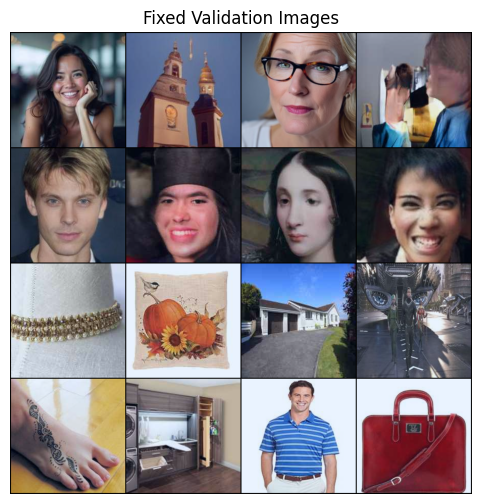

Fake: 034747.png
Fake: 032677.png
Fake: 022500.png
Fake: 011576.png
Fake: 013410.png
Fake: 033101.png
Fake: 001310.png
Fake: 007816.png
Real: 0020916.png
Real: 0009584.png
Real: 0014259.png
Real: 0016295.png
Real: 0007632.png
Real: 0000789.png
Real: 0005401.png
Real: 0015800.png


In [31]:
# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
grid_size = 4
num_images = grid_size * grid_size

if isinstance(val_dataset, torch.utils.data.Subset):
    subset = val_dataset
    base = val_dataset.dataset

    all_indices = subset.indices
    all_paths  = [base.samples[i][0] for i in all_indices]
    all_labels = [base.samples[i][1] for i in all_indices]

else:
    all_paths  = [p for p, l in val_dataset.samples]
    all_labels = [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

if isinstance(val_dataset, torch.utils.data.Subset):
    base = val_dataset.dataset
    original_indices = [all_indices[i.item()] for i in subset_indices]

    fixed_images = torch.stack([base[i][0] for i in original_indices]).to(device)
    fixed_labels = torch.tensor([base[i][1] for i in original_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

else:
    fixed_images = torch.stack([val_dataset[i][0] for i in subset_indices]).to(device)
    fixed_labels = torch.tensor([val_dataset[i][1] for i in subset_indices]).to(device)
    fixed_paths  = [all_paths[i] for i in subset_indices]

#UPDATE FOR FFT
fixed_rgb = fixed_images[:, :3, :, :]   # shape (N, 3, H, W)

grid_img = make_grid(fixed_rgb.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")


In [32]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_pbar = tqdm(train_loader, desc="Training", unit="batch")
    for images, labels, _ in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
        train_acc = 100.0 * correct / total

        train_pbar.set_postfix({
            "Loss": f"{avg_loss:.4f}",
            "Train Acc": f"{train_acc:.2f}%"
        })

    avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)
    train_acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, train_acc


def eval_accuracy(model, loader, device, desc="Evaluating"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, unit="batch", leave=False)
        for images, labels, _ in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = 100.0 * correct / total if total > 0 else 0.0
    return acc


In [ ]:
def sliding_window_training(
    model,
    criterion,
    optimizer,
    train_dataset,
    val_dataset,
    train_real_indices,
    train_fake_indices_by_w,
    val_real_indices,
    val_fake_indices_by_w,
    max_w,
    num_epochs_per_step,
    batch_size,
    device,
    model_name="Temporal_ViT",
    num_workers=0,
    csv_name_used = None
):
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if csv_name_used is None:
        csv_name_used = "none provided"

    params = {
        "model": model_name,
        "dataset split used:": csv_name_used,
        "max_w": max_w,
        "epochs_per_step": num_epochs_per_step,
        "batch_size": batch_size,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }

    log_txt, log_json_path, json_log = create_run_logger(
        model_name=model_name,
        params=params,
        timestamp=timestamp
    )

    # Log device + dataset sizes
    device_info = str(device)
    if device.type == "cuda":
        device_info += f" ({torch.cuda.get_device_name(0)})"
        print(f"Using device: {device_info}")
    else:
        device_info += " (CPU)"
        print(f"Using device: {device_info}")

    with open(log_txt, "a") as f:
        f.write(f"Using device: {device_info}\n")
        f.write(f"Using dataset: {csv_name_used}\n")
        f.write(f"Using model: {model_name }\n")
        f.write(f"Using max sliding window: {max_w}\n")
        f.write(f"Using epochs per step: {num_epochs_per_step}\n")
        f.write(f"Using batch size: {batch_size}\n")
        f.write(f"Using learning rate: {optimizer.param_groups[0]['lr']}\n")
        f.write(f"Dataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}\n\n")

    history = []
    start_time = time.time()
    best_val_acc = 0

    for k in range(0, max_w):  # last step is k=max_w-1 with next window = max_w
        print("\n" + "="*70)
        print(f" - Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }")
        print("="*70)

        logger_add_step(
            json_log,
            step_index=k,
            windows_used=list(range(0, k+1))
        )

        past_windows = list(range(0, k+1))
        next_window  = k + 1
        all_up_to_next = list(range(0, max_w+1))

        # Build loaders
        train_loader, n_train = make_loader_for_windows(
            train_dataset,
            train_real_indices,
            train_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers
        )

        val_past_loader, n_val_past = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            past_windows,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_next_loader, n_val_next = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            [next_window],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        val_all_loader, n_val_all = make_loader_for_windows(
            val_dataset,
            val_real_indices,
            val_fake_indices_by_w,
            all_up_to_next,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers
        )

        print(f"Train: {n_train} samples (Real + Fake windows {past_windows})")
        print(f"Val past: {n_val_past} samples (windows {past_windows})")
        print(f"Val next: {n_val_next} samples (window {next_window})")
        print(f"Val all: {n_val_all} samples (windows {all_up_to_next})")

        with open(log_txt, "a") as f:
            f.write(f"Step: {k}\n")
            f.write(f" * Sliding step {k}: train on w[0..{k}], validate on w{ k+1 }\n")
            f.write(f"Train: {n_train} samples (Real + Fake windows {past_windows})\n")
            f.write(f"Val past: {n_val_past} samples (windows {past_windows})\n")
            f.write(f"Val next: {n_val_next} samples (window {next_window})\n")
            f.write(f"Val all: {n_val_all} samples (windows {all_up_to_next})\n\n")

        # Train for num_epochs_per_step on current window setup
        for epoch in range(num_epochs_per_step):
            epoch_start_time = time.time()
            print(f"\n[Step {k}] Epoch {epoch+1}/{num_epochs_per_step}")

            train_loss, train_acc = train_one_epoch(
                model, train_loader, criterion, optimizer, device
            )

            # # Three validations
            # acc_past = eval_accuracy(model, val_past_loader, device, desc="Val past")
            # acc_next = eval_accuracy(model, val_next_loader, device, desc="Val next")
            # acc_all = eval_accuracy(model, val_all_loader,  device, desc="Val all")

            metrics_past = eval_metrics_temporal(
            model,
            val_past_loader,
            device,
            desc="Val past",
            fake_indices_by_w=val_fake_indices_by_w,
            current_seen_windows=past_windows)

            metrics_next = eval_metrics_temporal(
            model,
            val_next_loader,
            device,
            desc="Val Next",
            fake_indices_by_w=val_fake_indices_by_w,
            current_seen_windows=[next_window])

            metrics_all = eval_metrics_temporal(
            model,
            val_all_loader,
            device,
            desc="Val All",
            fake_indices_by_w=val_fake_indices_by_w,
            current_seen_windows=all_up_to_next)

            # Accuracy
            acc_past = metrics_past["accuracy"]
            acc_next = metrics_next["accuracy"]
            acc_all = metrics_all["accuracy"]

            # Precision
            prec_past = metrics_past['precision_macro']
            prec_next = metrics_next['precision_macro']
            prec_all = metrics_all['precision_macro']

            # Recall
            recall_past = metrics_past['recall_macro']
            recall_next = metrics_next['recall_macro']
            recall_all = metrics_all['recall_macro']

            # F1
            f1_past = metrics_past['f1_macro']
            f1_next = metrics_next['f1_macro']
            f1_all = metrics_all['f1_macro']

            # SEEN F1
            seen_f1_past = metrics_past['seen_f1']
            seen_f1_next = metrics_next['seen_f1']
            seen_f1_all = metrics_all['seen_f1']

            # SEEN F1
            unseen_f1_past = metrics_past['unseen_f1']
            unseen_f1_next = metrics_next['unseen_f1']
            unseen_f1_all = metrics_all['unseen_f1']

            # ROC-AUC
            aroc_past = metrics_past['roc_auc']
            aroc_next = metrics_next['roc_auc']
            aroc_all = metrics_all['roc_auc'] 

            print(
                f"[Step {k} | Epoch {epoch+1}] \n"
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | \n"
                f"Acc_ValPast: {acc_past:.2f}% | Acc_ValNext: {acc_next:.2f}% | Acc_ValAll: {acc_all:.2f}% \n"
                f"Prec_ValPast: {prec_past:.2f}% | Prec_ValNext: {prec_next:.2f}% | Prec_ValAll: {prec_all:.2f}% \n"
                f"Recall_ValPast: {recall_past:.2f}% | Recall_ValNext: {recall_next:.2f}% | Recall_ValAll: {recall_all:.2f}% \n"
                f"F1_ValPast: {f1_past:.2f}% | F1_ValNext: {f1_next:.2f}% | F1_ValAll: {f1_all:.2f}% \n"
                f"Seen_F1_ValPast: {seen_f1_past:.2f}% | Seen_F1_ValNext: {seen_f1_next:.2f}% | Seen_F1_ValAll: {seen_f1_all:.2f}% \n"
                f"Unseen_F1_ValPast: {unseen_f1_past:.2f}% | Unseen_F1_ValNext: {unseen_f1_next:.2f}% | Unseen_F1_ValAll: {unseen_f1_all:.2f}% \n"
                f"AROC_ValPast: {aroc_past:.2f} | AROC_ValNext: {aroc_next:.2f} | AROC_ValAll: {aroc_all:.2f} \n"
            )

            history.append({
                "step": k,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                ########################
                "val_past_acc": acc_past,
                "val_next_acc": acc_next,
                "val_all_acc": acc_all,
                #######################
                "val_past_prec": prec_past,
                "val_next_prec": prec_next,
                "val_all_prec": prec_all,
                #######################
                "val_past_recall": recall_past,
                "val_next_recall": recall_next,
                "val_all_recall": recall_all,
                #######################
                "val_past_f1": f1_past,
                "val_next_f1": f1_next,
                "val_all_f1": f1_all,
                #######################
                "val_past_seenf1": seen_f1_past,
                "val_next_seenf1": seen_f1_next,
                "val_all_seenf1": seen_f1_all,
                #######################
                "val_past_unseenf1": unseen_f1_past,
                "val_next_unseenf1": unseen_f1_next,
                "val_all_unseenf1": unseen_f1_all,
                #######################
                "val_past_aroc": aroc_past,
                "val_next_aroc": aroc_next,
                "val_all_aroc": aroc_all
            })
            total_epoch_minutes = (time.time() - epoch_start_time) / 60.0

            logger_add_epoch(
                json_log,
                step_index=k,
                epoch_index=epoch+1,
                metrics={
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    #######################
                    "val_past_acc": acc_past,
                    "val_next_acc": acc_next,
                    "val_all_acc": acc_all,
                    #######################
                    "val_past_prec": prec_past,
                    "val_next_prec": prec_next,
                    "val_all_prec": prec_all,
                    #######################
                    "val_past_recall": recall_past,
                    "val_next_recall": recall_next,
                    "val_all_recall": recall_all,
                    #######################
                    "val_past_f1": f1_past,
                    "val_next_f1": f1_next,
                    "val_all_f1": f1_all,
                    #######################
                    "val_past_seenf1": seen_f1_past,
                    "val_next_seenf1": seen_f1_next,
                    "val_all_seenf1": seen_f1_all,
                    #######################
                    "val_past_unseenf1": unseen_f1_past,
                    "val_next_unseenf1": unseen_f1_next,
                    "val_all_unseenf1": unseen_f1_all,
                    #######################
                    "val_past_aroc": aroc_past,
                    "val_next_aroc": aroc_next,
                    "val_all_aroc": aroc_all,
                    "epoch_minutes": total_epoch_minutes
                }
            )

            with open(log_txt, "a") as f:
                f.write(f"Step: {k} ; Epoch = : {epoch+1}\n")
                f.write(f"\tTrain Loss: {train_loss} ; Train Acc {train_acc}\n")
                f.write(f"\tVal Past Acc: {acc_past}\n")
                f.write(f"\tVal Next Acc: {acc_next}\n")
                f.write(f"\tVal All Acc: {acc_all}\n")
                ################################################
                f.write(f"\tVal Past Prec: {prec_past}\n")
                f.write(f"\tVal Next Prec: {prec_next}\n")
                f.write(f"\tVal All Prec: {prec_all}\n")
                ################################################
                f.write(f"\tVal Past Recall: {recall_past}\n")
                f.write(f"\tVal Next Recall: {recall_next}\n")
                f.write(f"\tVal All Recall: {recall_all}\n")
                ################################################
                f.write(f"\tVal Past F1: {f1_past}\n")
                f.write(f"\tVal Next F1: {f1_next}\n")
                f.write(f"\tVal All F1: {f1_all}\n")
                ################################################
                f.write(f"\tVal Past Seen F1: {seen_f1_past}\n")
                f.write(f"\tVal Next Seen F1: {seen_f1_next}\n")
                f.write(f"\tVal All Seen F1: {seen_f1_all}\n")
                ################################################
                f.write(f"\tVal Past Unseen F1: {unseen_f1_past}\n")
                f.write(f"\tVal Next Unseen F1: {unseen_f1_next}\n")
                f.write(f"\tVal All Unseen F1: {unseen_f1_all}\n")
                ################################################
                f.write(f"\tVal Past AROC: {aroc_past}\n")
                f.write(f"\tVal Next AROC: {aroc_next}\n")
                f.write(f"\tVal All AROC: {aroc_all}\n")

                if epoch+1 == num_epochs_per_step:
                    f.write(f"\tTotal Epoch Minutes {total_epoch_minutes:.2f}\n\n")
                    f.write(f"{'='*30}\n")
                else:
                    f.write(f"\tTotal Epoch Minutes {total_epoch_minutes:.2f}\n")

            if acc_all > best_val_acc:
                best_val_acc = acc_all
                torch.save(model.state_dict(), f"best_{model_name}_{timestamp}.pth")

            save_json_log(json_log, log_json_path)

            print(f"Total Epoch time: {total_epoch_minutes:.2f} minutes")

    total_minutes = (time.time() - start_time) / 60.0
    print(f"\nSliding-window training complete in {total_minutes:.2f} minutes.")

    with open(log_txt, "a") as f:
        f.write(f"Best Validation accuracy for all windows: {best_val_acc}")
        f.write(f"Training Complete in: {total_minutes:.2f} minutes.")

    return history

## Training

In [34]:
num_epochs_per_step = 1

history = sliding_window_training(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    train_real_indices=train_real_indices,
    train_fake_indices_by_w=train_fake_indices_by_w,
    val_real_indices=val_real_indices,
    val_fake_indices_by_w=val_fake_indices_by_w,
    max_w=max_w,
    num_epochs_per_step=num_epochs_per_step,
    batch_size=batch_size,
    device=device,
    model_name="NEW_nonzero_Temporal_ViT_FFT",
    num_workers=0,
    csv_name_used=csv_name
)

Using device: cuda (NVIDIA GeForce RTX 4070 Ti)

 - Sliding step 0: train on w[0..0], validate on w1
Train: 63964 samples (Real + Fake windows [0])
Val past: 15715 samples (windows [0])
Val next: 15774 samples (window 1)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 0] Epoch 1/1


Training: 100%|██████████| 3998/3998 [16:51<00:00,  3.95batch/s, Loss=0.3465, Train Acc=92.28%]


[Step 0 | Epoch 1] 
Train Loss: 0.3465 | Train Acc: 92.28% | 
Acc_ValPast: 92.41% | Acc_ValNext: 91.21% | Acc_ValAll: 53.14% 
Prec_ValPast: 90.08% | Prec_ValNext: 87.21% | Prec_ValAll: 73.11% 
Recall_ValPast: 63.06% | Recall_ValNext: 58.34% | Recall_ValAll: 53.14% 
F1_ValPast: 68.34% | F1_ValNext: 61.83% | F1_ValAll: 40.24% 
Seen_F1_ValPast: 41.94% | Seen_F1_ValNext: 29.18% | Seen_F1_ValAll: 12.50% 
Unseen_F1_ValPast: nan% | Unseen_F1_ValNext: nan% | Unseen_F1_ValAll: nan% 
AROC_ValPast: 0.87 | AROC_ValNext: 0.85 | AROC_ValAll: 0.79 

Total Epoch time: 26.83 minutes

 - Sliding step 1: train on w[0..1], validate on w2
Train: 70419 samples (Real + Fake windows [0, 1])
Val past: 17319 samples (windows [0, 1])
Val next: 15694 samples (window 2)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 1] Epoch 1/1


Training: 100%|██████████| 4402/4402 [23:55<00:00,  3.07batch/s, Loss=0.4015, Train Acc=88.37%]


[Step 1 | Epoch 1] 
Train Loss: 0.4015 | Train Acc: 88.37% | 
Acc_ValPast: 89.17% | Acc_ValNext: 90.39% | Acc_ValAll: 70.69% 
Prec_ValPast: 82.87% | Prec_ValNext: 72.46% | Prec_ValAll: 77.12% 
Recall_ValPast: 78.94% | Recall_ValNext: 71.11% | Recall_ValAll: 70.69% 
F1_ValPast: 80.67% | F1_ValNext: 71.75% | F1_ValAll: 68.84% 
Seen_F1_ValPast: 77.18% | Seen_F1_ValNext: 64.11% | Seen_F1_ValAll: 63.33% 
Unseen_F1_ValPast: nan% | Unseen_F1_ValNext: nan% | Unseen_F1_ValAll: nan% 
AROC_ValPast: 0.91 | AROC_ValNext: 0.88 | AROC_ValAll: 0.85 

Total Epoch time: 37.53 minutes

 - Sliding step 2: train on w[0..2], validate on w3
Train: 76920 samples (Real + Fake windows [0, 1, 2])
Val past: 18843 samples (windows [0, 1, 2])
Val next: 15740 samples (window 3)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 2] Epoch 1/1


...

[Step 5 | Epoch 1] 
Train Loss: 0.4537 | Train Acc: 82.94% | 
Acc_ValPast: 84.28% | Acc_ValNext: 87.60% | Acc_ValAll: 75.61% 
Prec_ValPast: 84.34% | Prec_ValNext: 67.91% | Prec_ValAll: 78.21% 
Recall_ValPast: 82.62% | Recall_ValNext: 73.57% | Recall_ValAll: 75.61% 
F1_ValPast: 83.25% | F1_ValNext: 70.12% | F1_ValAll: 75.04% 
Seen_F1_ValPast: 85.25% | Seen_F1_ValNext: 71.85% | Seen_F1_ValAll: 75.34% 
Unseen_F1_ValPast: nan% | Unseen_F1_ValNext: nan% | Unseen_F1_ValAll: nan% 
AROC_ValPast: 0.92 | AROC_ValNext: 0.86 | AROC_ValAll: 0.87 

Total Epoch time: 36.96 minutes

 - Sliding step 6: train on w[0..6], validate on w7
Train: 102354 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6])
Val past: 25166 samples (windows [0, 1, 2, 3, 4, 5, 6])
Val next: 15757 samples (window 7)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 6] Epoch 1/1


Training: 100%|██████████| 6398/6398 [29:45<00:00,  3.58batch/s, Loss=0.4656, Train Acc=82.11%]  


[Step 6 | Epoch 1] 
Train Loss: 0.4656 | Train Acc: 82.11% | 
Acc_ValPast: 82.77% | Acc_ValNext: 82.03% | Acc_ValAll: 76.08% 
Prec_ValPast: 83.01% | Prec_ValNext: 53.61% | Prec_ValAll: 77.94% 
Recall_ValPast: 81.87% | Recall_ValNext: 54.14% | Recall_ValAll: 76.08% 
F1_ValPast: 82.23% | F1_ValNext: 53.82% | F1_ValAll: 75.68% 
Seen_F1_ValPast: 85.53% | Seen_F1_ValNext: 32.24% | Seen_F1_ValAll: 77.44% 
Unseen_F1_ValPast: nan% | Unseen_F1_ValNext: nan% | Unseen_F1_ValAll: nan% 
AROC_ValPast: 0.91 | AROC_ValNext: 0.68 | AROC_ValAll: 0.86 

Total Epoch time: 41.17 minutes

 - Sliding step 7: train on w[0..7], validate on w8
Train: 108741 samples (Real + Fake windows [0, 1, 2, 3, 4, 5, 6, 7])
Val past: 26753 samples (windows [0, 1, 2, 3, 4, 5, 6, 7])
Val next: 15757 samples (window 8)
Val all: 28340 samples (windows [0, 1, 2, 3, 4, 5, 6, 7, 8])

[Step 7] Epoch 1/1


Training: 100%|██████████| 6797/6797 [57:31<00:00,  1.97batch/s, Loss=0.5019, Train Acc=78.87%]  


[Step 7 | Epoch 1] 
Train Loss: 0.5019 | Train Acc: 78.87% | 
Acc_ValPast: 77.65% | Acc_ValNext: 86.23% | Acc_ValAll: 74.45% 
Prec_ValPast: 80.78% | Prec_ValNext: 59.05% | Prec_ValAll: 78.64% 
Recall_ValPast: 76.64% | Recall_ValNext: 57.32% | Recall_ValAll: 74.45% 
F1_ValPast: 76.56% | F1_ValNext: 58.01% | F1_ValAll: 73.48% 
Seen_F1_ValPast: 74.76% | Seen_F1_ValNext: 34.86% | Seen_F1_ValAll: 71.25% 
Unseen_F1_ValPast: nan% | Unseen_F1_ValNext: nan% | Unseen_F1_ValAll: nan% 
AROC_ValPast: 0.89 | AROC_ValNext: 0.77 | AROC_ValAll: 0.88 

Total Epoch time: 134.09 minutes

Sliding-window training complete in 377.58 minutes.


In [35]:
hist_df = pd.DataFrame(history)
print(hist_df.head())


   step  epoch  train_loss  train_acc  val_past_acc  val_next_acc  \
0     0      1    0.346475  92.283159     92.408527     91.213389   
1     1      1    0.401530  88.368196     89.173740     90.391232   
2     2      1    0.434356  85.032501     84.227565     92.147395   
3     3      1    0.445342  83.954144     84.700926     92.549144   
4     4      1    0.444641  83.773012     83.400718     81.438721   

   val_all_acc  val_past_prec  val_next_prec  val_all_prec  ...  val_all_f1  \
0    53.143966      90.081375      87.209272     73.112008  ...   40.235255   
1    70.688073      82.869350      72.461087     77.120640  ...   68.840441   
2    62.674665      88.638373      85.820057     77.086422  ...   56.948047   
3    71.153846      84.991944      79.358412     77.751253  ...   69.331088   
4    77.579393      81.920617      64.749401     77.797792  ...   77.535268   

   val_past_seenf1  val_next_seenf1  val_all_seenf1  val_past_unseenf1  \
0        41.943734        29.179979 